In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv(r"C:\Users\User\Desktop\archive (1)\1553768847-housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


In [3]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [4]:
df['Near By']=df['ocean_proximity']=='NEAR BAY'
df['inland']=df['ocean_proximity']=='INLAND'
df['<1H OCEAN']=df['ocean_proximity']=='<1H OCEAN'
df['NEAR OCEAN']=df['ocean_proximity']=='NEAR OCEAN'
df['ISLAND']=df['ocean_proximity']=='ISLAND'
df=df.drop(columns=['ocean_proximity'])

In [5]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,Near By,inland,<1H OCEAN,NEAR OCEAN,ISLAND
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,False,True,False,False,False
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,False,True,False,False,False
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,False,True,False,False,False
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,False,True,False,False,False
20639,-121.24,39.37,16,2785,616.0,1387,530,2.3886,89400,False,True,False,False,False


In [6]:
df=df.drop(columns=['<1H OCEAN'])

In [7]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,Near By,inland,NEAR OCEAN,ISLAND
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,True,False,False,False
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,True,False,False,False
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,True,False,False,False
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,True,False,False,False
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,False,True,False,False
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,False,True,False,False
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,False,True,False,False
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,False,True,False,False


In [8]:
df.shape

(20640, 13)

In [9]:
# df=df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   Near By             20640 non-null  bool   
 10  inland              20640 non-null  bool   
 11  NEAR OCEAN          20640 non-null  bool   
 12  ISLAND              20640 non-null  bool   
dtypes: bool(4), float64(4), int64(5)
memory usage: 1.5 MB


In [11]:
df['total_bedrooms']=df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   Near By             20640 non-null  bool   
 10  inland              20640 non-null  bool   
 11  NEAR OCEAN          20640 non-null  bool   
 12  ISLAND              20640 non-null  bool   
dtypes: bool(4), float64(4), int64(5)
memory usage: 1.5 MB


In [18]:
class myLinearRegression:
    def __init__(self):
        self.b=None
        self.y=None
        self.x=None
    def fit(self,x,y):
        self.x=np.array(x,dtype=np.float64)
        self.y=np.array(y,dtype=np.float64)
        self.x = np.c_[np.ones((self.x.shape[0], 1)), self.x]
        a=np.transpose(self.x).dot(self.x)
        a=np.linalg.inv(a)
        b=np.transpose(self.x).dot(y)
        self.b=a.dot(b)
        return self.b
    def predict(self):
        print(x.shape)
        print(self.b.shape)
        
        return self.x.dot(self.b)
y=df.iloc[:,8]
x=df.drop(columns=["median_house_value"])
model=myLinearRegression()
b=model.fit(x,y)
y_predict=model.predict()
y_predict


(20640, 12)
(13,)


array([408492.35829873, 423996.66388606, 378466.63041495, ...,
        40399.75324087,  50937.88670859,  67523.43037015], shape=(20640,))

In [19]:
y=np.array(y)

In [20]:
y

array([452600, 358500, 352100, ...,  92300,  84700,  89400],
      shape=(20640,))

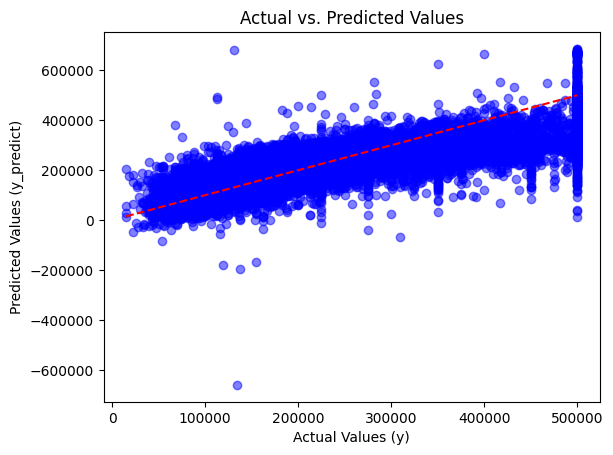

In [23]:

plt.scatter(y, y_predict, alpha=0.5, color='blue')

plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')

plt.xlabel('Actual Values (y)')
plt.ylabel('Predicted Values (y_predict)')
plt.title('Actual vs. Predicted Values')

plt.show()